## 下载数据集

In [205]:
# 导入所需的库
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
from d2l import torch as d2l

In [206]:
path = r"house-prices-advanced-regression-techniques"
train_data_dir = os.path.join(path, 'train.csv')
test_data_dir = os.path.join(path, 'test.csv')
data_train = pd.read_csv(train_data_dir)
data_test = pd.read_csv(test_data_dir)
print(data_train.shape)
print(data_test.shape)


(1460, 81)
(1459, 80)


In [207]:
# 查看数据信息
print(data_train.iloc[0:4, [1, 2, 3, -3, -2, -1]])

   MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0          60       RL         65.0       WD        Normal     208500
1          20       RL         80.0       WD        Normal     181500
2          60       RL         68.0       WD        Normal     223500
3          70       RL         60.0       WD       Abnorml     140000


In [208]:
all_features = pd.concat((data_train.iloc[:, 1:-1], data_test.iloc[:, 1:]))
print(all_features.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

   MSSubClass MSZoning  LotFrontage  LotArea  YrSold SaleType SaleCondition
0          60       RL         65.0     8450    2008       WD        Normal
1          20       RL         80.0     9600    2007       WD        Normal
2          60       RL         68.0    11250    2008       WD        Normal
3          70       RL         60.0     9550    2006       WD       Abnorml


数据预处理

In [209]:
numerical_features = all_features.dtypes[all_features.dtypes != 'object'].index #筛选出数值型特征
# 计算数值型特征的均值和标准差
all_features[numerical_features] = all_features[numerical_features].apply(
    lambda x: (x - x.mean())/x.std()
)
all_features[numerical_features] = all_features[numerical_features].fillna(0) #填充缺失值，0

In [210]:
# 处理离散型特征
all_features = pd.get_dummies(all_features, dummy_na=True, sparse=True) # 独热编码  # “Dummy_na=True”将“na”（缺失值）视为有效的特征值，并为其创建指示符特征
print(all_features.shape) #查看特征维度

(2919, 330)


In [211]:
# 将数据转换为张量
num_train = data_train.shape[0] # 训练集样本数
feature_train = torch.tensor(all_features[:num_train].values, dtype=torch.float32) # 训练集特征
feature_test = torch.tensor(all_features[num_train:].values, dtype=torch.float32) # 测试集特征
label_train = torch.tensor(data_train.SalePrice.values.reshape(-1, 1), dtype=torch.float32) # 训练集标签

/var/folders/xv/fxpsfdps3gvgrw0z_83tb7bm0000gn/T/ipykernel_26443/1991631600.py:3: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  feature_train = torch.tensor(all_features[:num_train].values, dtype=torch.float32) # 训练集特征
/var/folders/xv/fxpsfdps3gvgrw0z_83tb7bm0000gn/T/ipykernel_26443/1991631600.py:4: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  feature_test = torch.tensor(all_features[num_train:].values, dtype=torch.float32) # 测试集特征


## 训练

In [212]:
num_inputs = feature_train.shape[1] # 特征维度
num_outputs = 1 # 输出维度
batch_size = 64 # 批量大小
num_epochs = 100 # 训练轮数
lr = 5 # 学习率
k = 5 # K折交叉验证
weight_decay = 0.001 # 权重衰减

# 定义模型
def price_net():
    net = nn.Sequential(
        nn.Linear(num_inputs, num_outputs)# 输入层到隐藏层1
    )
    return net

In [213]:
# 定义损失函数
loss = nn.MSELoss()
# 定义评估函数
def log_rmse(net, y_pred, y_true):
    clapped = torch.clamp(net(y_pred), 1, float('inf'))
    fts_rmse = torch.sqrt(loss(torch.log(clapped), torch.log(y_true)))
    return fts_rmse.item() # 返回标量值

In [214]:
# 定义训练函数
def train(net, train_fts, train_lab, valid_fts, valid_lab, num_epochs, lr, weight_decay, batch_size):
    train_loss, valid_loss= [], []
    train_iter = d2l.load_array((train_fts, train_lab), batch_size) # 训练集迭代器
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
        train_loss.append(log_rmse(net, train_fts, train_lab))
        if valid_lab is not None: # 如果有验证集
            valid_loss.append(log_rmse(net, valid_fts, valid_lab))
    return train_loss, valid_loss

## 定义$K$折交叉验证函数

In [215]:
# 定义k折交叉验证函数
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None # X_train为训练集特征，y_train为训练集标签
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part # X_valid为验证集特征，y_valid为验证集标签
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

In [216]:
def k_fold(k, X_train, y_train, num_epochs, lr, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0 # train_l_sum为训练集总损失，valid_l_sum为验证集总损失
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = price_net()
        train_ls, valid_ls = train(net, *data, num_epochs, lr, weight_decay, batch_size) # train_ls为训练集损失，valid_ls为验证集损失
        train_l_sum += train_ls[-1] 
        valid_l_sum += valid_ls[-1]# 每一折训练完成后，将最后一个 epoch 的训练和验证损失累加到总损失中
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

## 模型选择

折1，训练log rmse0.170267, 验证log rmse0.156767
折2，训练log rmse0.162202, 验证log rmse0.189186
折3，训练log rmse0.164000, 验证log rmse0.168157
折4，训练log rmse0.168141, 验证log rmse0.154389
折5，训练log rmse0.163340, 验证log rmse0.182946
5折交叉验证，训练log rmse0.165590,0.170289验证log rmse


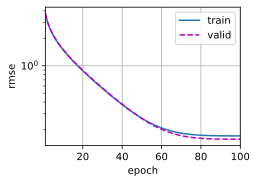

In [217]:
train_l, valid_l = k_fold(k, feature_train, label_train, num_epochs, lr, weight_decay, batch_size) # train_l为训练集log_rmse，valid_l为验证集log_rmse
print(f'{k}折交叉验证，训练log rmse{float(train_l):f},'
      f'{float(valid_l):f}验证log rmse')

## 提交代码预测

In [218]:
def train_and_predict(feature_train, label_train, feature_test, test_data, num_epochs, lr, weight_decay, batch_size):
    net = price_net()
    train_ls, _ = train(net, feature_train, label_train, None, None, num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(feature_test).detach().numpy()  # 使用detach()将张量从计算图中分离出来
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])  # 将预测结果添加到测试数据中
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)  # 合并ID和预测结果
    submission.to_csv('submission.csv', index=False)  # 保存为CSV文件

训练log rmse：0.162505


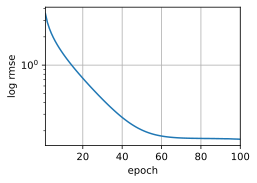

In [219]:
train_and_predict(feature_train, label_train, feature_test, data_test, num_epochs, lr, weight_decay, batch_size)